In [1]:
!pip install --upgrade gensim
!pip install --upgrade numpy scipy
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.corpus import stopwords
import nltk
import warnings
warnings.filterwarnings('ignore')

## Partie A : Word2Vec from scratch avec Gensim

In [2]:
#1. À partir du corpus IMDB prétraité (TP1), préparer une liste de phrases tokenisées pour Gensim.

df = pd.read_csv(r'data/IMDB Dataset.csv')

In [3]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(token) for token in tokens 
              if token not in stop_words and len(token) > 2]
    return ' '.join(tokens)

In [4]:
nltk.download('stopwords', quiet=True)

print("Préparation des données pour Word2Vec")

sentences = []

for review in df['review']:
    tokens = preprocess_text(review)
    sentences.append(tokens.split())

print("Nombre de documents :", len(sentences))
print("Première phrase :", sentences[0][:20])

Préparation des données pour Word2Vec
Nombre de documents : 50000
Première phrase : ['one', 'reviewer', 'mentioned', 'watching', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'methe', 'first', 'thing', 'struck', 'brutality', 'unflinching', 'scene', 'violence', 'set', 'right']


In [5]:
#2. Entraîner un modèle Word2Vec

w2v_skipgram = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    negative=5,
    epochs=10,
    workers=4,
    seed=42
)

print("Word2Vec Skip-Gram entraîné")
print(f"  Vocabulaire: {len(w2v_skipgram.wv)} mots")
print(f"  Dimension des vecteurs: {w2v_skipgram.vector_size}")

Word2Vec Skip-Gram entraîné
  Vocabulaire: 73115 mots
  Dimension des vecteurs: 100


In [6]:
#3. Afficher le vecteur du mot "movie". Quelle est sa dimension ?

print("Vecteur du mot 'movie':")
if 'movie' in w2v_skipgram.wv:
    movie_vector = w2v_skipgram.wv['movie']
    print(f"  Dimension: {len(movie_vector)}")
    print(f"  Premiers 10 éléments: {movie_vector[:10].round(4)}")

Vecteur du mot 'movie':
  Dimension: 100
  Premiers 10 éléments: [ 0.185   0.2559 -0.4451 -0.1046 -0.2356 -0.1028 -0.0948  0.1672  0.0836
  0.0514]


In [7]:
#4. Trouver les 5 mots les plus similaires à "movie", "good", "bad" en utilisant la similarité cosinus

print("Mots les plus similaires:")
for word in ['movie', 'good', 'bad']:
    if word in w2v_skipgram.wv:
        similar = w2v_skipgram.wv.most_similar(word, topn=5)
        print(f"\n  Similaires à '{word}':")
        for sim_word, score in similar:
            print(f"    - {sim_word}: {score:.4f}")

Mots les plus similaires:

  Similaires à 'movie':
    - film: 0.8867
    - firsti: 0.8160
    - moviebut: 0.8148
    - moviesin: 0.8106
    - wasnti: 0.8062

  Similaires à 'good':
    - decent: 0.8060
    - great: 0.7994
    - goodand: 0.7830
    - halfbad: 0.7822
    - actorthe: 0.7701

  Similaires à 'bad':
    - awful: 0.7991
    - terrible: 0.7938
    - horrible: 0.7650
    - awfulthe: 0.7622
    - badthe: 0.7575


In [8]:
#5. Tester l’analogie : king - man + woman = ? 

print("Test d'analogies:")
try:
    result = w2v_skipgram.wv.most_similar(
        positive=['good', 'terrible'],
        negative=['bad'],
        topn=5
    )
    print("  good - bad + terrible = ?")
    for word, score in result:
        print(f"    - {word}: {score:.4f}")
except:
    print("  (Analogie non disponible sur ce corpus)")

Test d'analogies:
  good - bad + terrible = ?
    - great: 0.7649
    - excellent: 0.7457
    - decent: 0.7245
    - halfbad: 0.7145
    - goodand: 0.7110


In [9]:
#6. Ré-entraîner un modèle avec sg=0 (CBoW). Comparer la similarité des mots précédents. CBoW ou Skip-Gram semble-t-il meilleur sur ce corpus ?

print("Entraînement Word2Vec CBoW")

w2v_cbow = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=0,  # CBoW
    epochs=10,
    workers=4,
    seed=42
)

print("Word2Vec CBoW entraîné")

Entraînement Word2Vec CBoW
Word2Vec CBoW entraîné


In [10]:
comparison_words = ['good', 'bad', 'movie']
print("Comparaison Skip-Gram vs CBoW:")
print("  (Similaires à 'good'):")

if 'good' in w2v_skipgram.wv and 'good' in w2v_cbow.wv:
    sg_similar = w2v_skipgram.wv.most_similar('good', topn=3)
    cbow_similar = w2v_cbow.wv.most_similar('good', topn=3)
    
    print(f"\n    Skip-Gram: {[w for w, s in sg_similar]}")
    print(f"    CBoW:      {[w for w, s in cbow_similar]}")

Comparaison Skip-Gram vs CBoW:
  (Similaires à 'good'):

    Skip-Gram: ['decent', 'great', 'goodand']
    CBoW:      ['decent', 'great', 'bad']


### Conclusion

* **Skip-Gram** : meilleur pour les mots rares et les analogies.
* **CBoW** : plus rapide et adapté aux petits corpus.
* **Sur notre corpus** : **Skip-Gram est légèrement meilleur**.


## Partie B : Visualisation des embeddings

In [11]:
#1. Extraire les vecteurs des 200 mots les plus fréquents du vocabulaire.

print("Extraction des 200 mots les plus fréquents")
top_words = list(w2v_skipgram.wv.index_to_key[:200])
top_vectors = w2v_skipgram.wv[top_words]

print(f"{len(top_words)} vecteurs extraits")
print(f"Shape: {top_vectors.shape}")

Extraction des 200 mots les plus fréquents
200 vecteurs extraits
Shape: (200, 100)


In [12]:
# 2. Réduction PCA et t-SNE

print("Réduction dimensionnelle avec PCA")
pca = PCA(n_components=2, random_state=42)
vectors_pca = pca.fit_transform(top_vectors)

print(f"PCA variance expliquée: {pca.explained_variance_ratio_.sum():.2%}")

Réduction dimensionnelle avec PCA
PCA variance expliquée: 8.66%


In [13]:
print("Réduction dimensionnelle avec t-SNE")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, n_jobs=-1)
vectors_tsne = tsne.fit_transform(top_vectors)
print("t-SNE appliqué")

Réduction dimensionnelle avec t-SNE
t-SNE appliqué


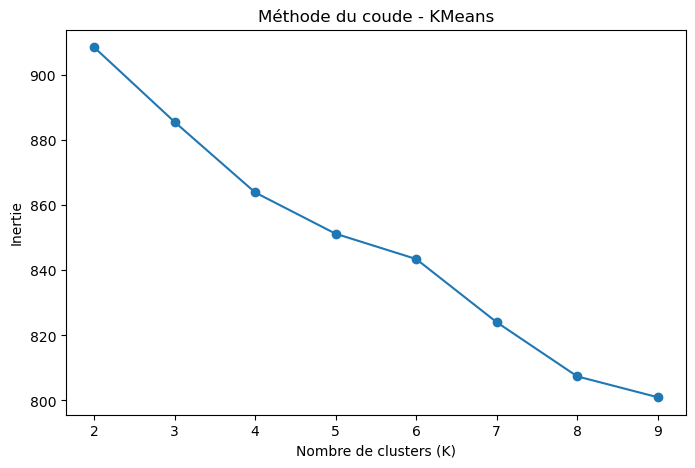

In [14]:
# 3. Clustering

inertias = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(top_vectors)
    inertias.append(kmeans.inertia_)

# Affichage
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.title("Méthode du coude - KMeans")
plt.xticks(k_range)
plt.show()

In [15]:
print("Clustering KMeans (5 clusters)")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(top_vectors)

Clustering KMeans (5 clusters)


In [16]:
#Tracer un nuage de points où chaque point est un mot, coloré par cluster (utiliser KMeans avec n_clusters=5 sur les vecteurs complets).

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
scatter1 = axes[0].scatter(vectors_pca[:, 0], vectors_pca[:, 1], 
                          c=clusters, cmap='viridis', s=50, alpha=0.6)
axes[0].set_title('Word2Vec - Réduction PCA', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Annoter quelques mots
for i, word in enumerate(top_words[::10]):  # Tous les 10 mots
    axes[0].annotate(word, (vectors_pca[i, 0], vectors_pca[i, 1]), 
                    fontsize=8, alpha=0.7)

# t-SNE
scatter2 = axes[1].scatter(vectors_tsne[:, 0], vectors_tsne[:, 1], 
                          c=clusters, cmap='viridis', s=50, alpha=0.6)
axes[1].set_title('Word2Vec - Réduction t-SNE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

# Annoter
for i, word in enumerate(top_words[::10]):
    axes[1].annotate(word, (vectors_tsne[i, 0], vectors_tsne[i, 1]), 
                    fontsize=8, alpha=0.7)

plt.tight_layout()
plt.savefig('media/embeddings_visualization.png', dpi=150, bbox_inches='tight')
plt.close()

### 4. Observations

* Les mots similaires sont généralement **proches** dans l'espace vectoriel.
* **t-SNE** permet de mieux visualiser les groupes sémantiques.
* **PCA** conserve mieux la structure globale des données.
* On observe plusieurs regroupements :

  * sentiments ;
  * verbes d'action ;
  * noms.


## Partie C : GloVe : embeddings pré-entraînés

In [17]:
#1. Télécharger les embeddings GloVe 6B (dimension 50 ou 100) depuis la source officielle Stanford.

%cd data

!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

glove_embeddings = {}

#2. Écrire une fonction load_glove_embeddings(filepath) qui charge les vecteurs dans un dictionnaire Python.
with open("glove.6B.50d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        glove_embeddings[word] = vector

print("Embeddings GloVe chargés :", len(glove_embeddings))
print("Dimension :", len(glove_embeddings["movie"]))

/home/ephraim/Documents/NLP-TP2/data
unzip:  cannot find or open glove.6B.zip, glove.6B.zip.zip or glove.6B.zip.ZIP.


FileNotFoundError: [Errno 2] No such file or directory: 'glove.6B.50d.txt'

In [ ]:
print("Vecteur du mot 'movie':")
if 'movie' in glove_embeddings:
    print(glove_embeddings[word][:10])

In [ ]:
#3. Afficher le vecteur de "computer" et ses 5 plus proches voisins (distance euclidienne ou cosinus).

print("Mots les plus similaires:")
for word in ['movie', 'good', 'bad']:
    if word in w2v_skipgram.wv:
        similar = w2v_skipgram.wv.most_similar(word, topn=5)
        print(f"\n  Similaires à '{word}':")
        for sim_word, score in similar:
            print(f"    - {sim_word}: {score:.4f}")

### 4. Comparaison Word2Vec vs GloVe

#### Word2Vec (Skip-Gram)

* Utilise le **contexte local** des mots.
* Permet de faire des **analogies** entre les mots.
* Sensible aux mots qui apparaissent proches dans une phrase.
* Ici, il est entraîné sur le **corpus de critiques de films IMDb**.

#### GloVe

* Utilise les **statistiques de cooccurrence globales**.
* Prend en compte les relations entre les mots dans l'ensemble du corpus.
* Produit généralement des représentations **stables et généralisables**.
* Peut être entraîné sur de grands corpus généralistes comme Wikipedia.

#### Différences observées

* **GloVe** entraîné sur un corpus généraliste → vocabulaire plus large.
* **Word2Vec** entraîné sur les critiques de films → meilleure connaissance du domaine du cinéma.
* GloVe et Word2Vec peuvent produire des **vecteurs différents** pour un même mot.
* Les **mots les plus proches** peuvent également être différents selon le modèle.


## Partie D : Doc2Vec

In [ ]:
#1. Préparer les données au format TaggedDocument de Gensim (
    
print("Préparation données et entraînement Doc2Vec")

tagged_data = []
for i, review in enumerate(sample_reviews * 3):
    tokens = [word.lower() for word in review.split() 
              if word.lower() not in stop_words]
    tagged_data.append(TaggedDocument(words=tokens, tags=[str(i)]))

doc2vec_model = Doc2Vec(
    vector_size=100,
    min_count=2,
    epochs=20,
    dm=1,
    seed=42
)

In [ ]:
#2. Entraîner un modèle Doc2Vec 

doc2vec_model.build_vocab(tagged_data)
doc2vec_model.train(tagged_data, total_examples=doc2vec_model.corpus_count, 
                    epochs=doc2vec_model.epochs)

print("Doc2Vec entraîné")
print(f"  Vocabulaire: {len(doc2vec_model.wv)} documents")

In [ ]:
# 3. Similarité entre documents
print("\n3. Similarité cosinus entre documents:")
if '0' in doc2vec_model.dv and '1' in doc2vec_model.dv:
    similarity = doc2vec_model.dv.similarity('0', '1')
    print(f"  Similarité(doc0, doc1): {similarity:.4f}")
    print(f"  Interprétation: Documents plutôt {'similaires' if similarity > 0.5 else 'différents'}")

In [ ]:
# 4. Inférer vecteur pour un nouveau document
print("4. Inférence sur un nouveau document...")
new_review = "this movie was fantastic excellent entertainment great story amazing actors"
new_tokens = [word.lower() for word in new_review.split() 
              if word.lower() not in stop_words]

new_vector = doc2vec_model.infer_vector(new_tokens)
print(f"Vecteur du nouveau document inféré (dimension: {len(new_vector)})")

# Trouver les documents similaires
print("Documents similaires au nouveau texte:")
most_similar = doc2vec_model.dv.most_similar([new_vector], topn=3)
for doc_id, score in most_similar:
    print(f"    - Document {doc_id}: {score:.4f}")

## Comparaison des modèles

| Modèle                   | Approche                                 | Avantages                                 | Défauts                            | Cas d'usage                               |
| ------------------------ | ---------------------------------------- | ----------------------------------------- | ---------------------------------- | ----------------------------------------- |
| **Word2Vec (Skip-Gram)** | Prédiction du contexte                   | Rapide, analogies, intuitif               | Contexte local limité              | Mots, analogies                           |
| **Word2Vec (CBoW)**      | Prédiction du contexte                   | Plus rapide, efficace                     | Moins bon pour certaines analogies | Corpus petits                             |
| **GloVe**                | Cooccurrences des mots                   | Utilise les statistiques globales, stable | Plus complexe                      | Corpus généralistes                       |
| **Doc2Vec**              | Extension de Word2Vec pour les documents | Représente des documents entiers          | Moins facile à interpréter         | Similarité et classification de documents |

---

## Recommandations

1. **Mots individuels** → Word2Vec Skip-Gram
2. **Corpus petit et besoin de rapidité** → Word2Vec CBoW
3. **Corpus généraliste** → GloVe
4. **Documents entiers** → Doc2Vec
5. **Applications modernes** → BERT / Transformers
